# Chapter 13: Matrix Encoding
---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [1]:
# Setup and imports
import numpy as np
from scipy.sparse import diags
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit.circuit.library import QFT, phase_estimation, HamiltonianGate
from qiskit.quantum_info import SparsePauliOp
from Chapter03_EngineeringOptimization_functions import PlaneStressCantilever
from qiskit.circuit.library import  StatePreparation,DiagonalGate, ZGate, XGate, RYGate, UCGate
from Chapter03_EngineeringOptimization_functions import (truss2x2,truss3x2,truss2x3,truss3x3,truss_10bar,
                                                         PlaneStressCantilever)
from Chapter08_QuantumGates_functions import  (simulate_statevector,  simulate_measurements, 
                                              estimateCircuitGates, findActualHardwareRequirements)
from Chapter13_MatrixEncoding_functions import (LCU_Ax, LCU_fTAx, Pauli_Block_Encoding)


## Weighted Unitary Multiplications

### Create gates that we need

In [2]:
Z_matrix = np.array([[1, 0], [0, -1]], dtype=complex)
X_matrix = np.array([[0, 1], [1,  0]], dtype=complex)

Z_gate = UnitaryGate(Z_matrix, label='Z')
X_gate = UnitaryGate(X_matrix, label='X')


### Single Gate

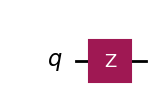

In [3]:
qc = QuantumCircuit(1)
qc.append(Z_gate, [0])
display(qc.draw('mpl'))

### Two Gates: Equal Probability

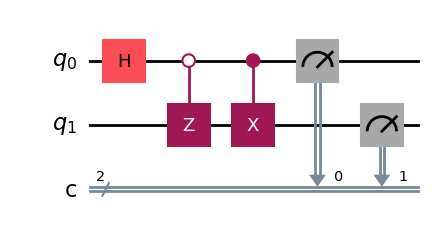

Measurement Counts: {'11': 490, '00': 510}


In [4]:
qc = QuantumCircuit(2, 2)
qc.h(0)    
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))
counts = simulate_measurements(qc, shots=1000)
print("Measurement Counts:", counts)

### Two gates: unequal probability

Resulting Statevector:


<IPython.core.display.Latex object>

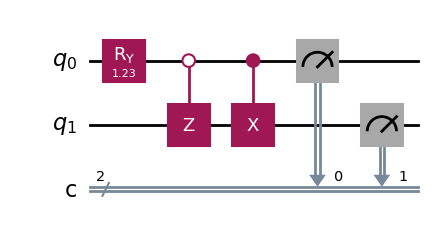

Measurement Counts: {'11': 344, '00': 656}


In [5]:
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1] / c[0]))
qc.ry(theta, 0)  
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))
counts = simulate_measurements(qc, shots=1000)
print("Measurement Counts:", counts)

### Two gates applied together

Resulting Statevector:


<IPython.core.display.Latex object>

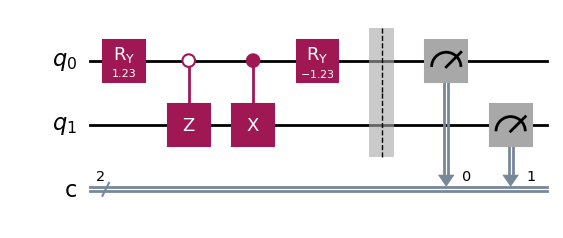

Counts: {'11': 211, '00': 458, '10': 111, '01': 220}


In [6]:
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1] / c[0]))
qc.ry(theta, 0)                      
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.ry(-theta, 0)        
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
qc.barrier()
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))

counts = simulate_measurements(qc, shots=1000)
print("Counts:", counts)

## LCU Example 1
### Step 1: Prepare state and coefficients

Classical y: [0.66666667 0.33333333]
Resulting Statevector:


<IPython.core.display.Latex object>

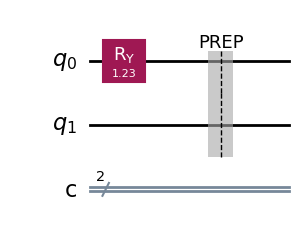

In [7]:
# A = [2/3 1/3; 1/3 -2/3]
# A = 2/3*Z + 1/3*X
# x = [1,0]

A = np.array([[2/3, 1/3], [1/3, 2/3]])

x= np.array([1,0])
y_classical = A @ x
print("Classical y:", y_classical)
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1]/c[0]))
qc.ry(theta, 0)  
qc.barrier(label = "PREP")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 2: Apply controlled operations

Resulting Statevector:


<IPython.core.display.Latex object>

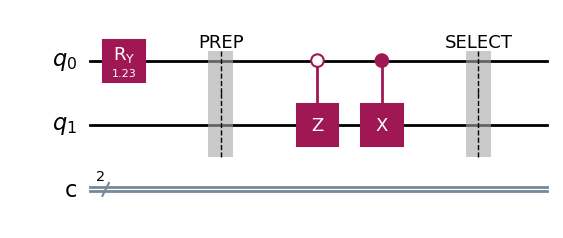

In [8]:
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.barrier(label = "SELECT")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 3: Ancilla clean up 

Resulting Statevector:


<IPython.core.display.Latex object>

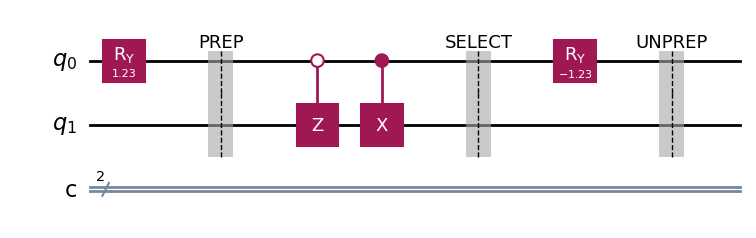

In [9]:
qc.ry(-theta, 0)
qc.barrier(label = "UNPREP")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 4: measurement

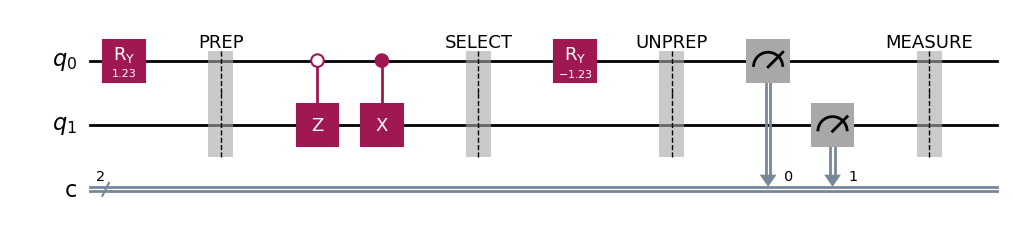

Measurement Counts: {'00': 4478, '10': 1061, '11': 2252, '01': 2209}


In [10]:
qc.measure(0, 0)   # measure ancilla q0 -> classical bit 0
qc.measure(1, 1)   # measure system  q1 -> classical bit 1
qc.barrier(label = "MEASURE")
display(qc.draw('mpl'))
nShots = 10000
counts = simulate_measurements(qc, shots=nShots)
print("Measurement Counts:", counts)



### A*x: Coefficient scaling

Full statevector: [ 0.6667-0.j -0.4714+0.j  0.3333+0.j  0.4714+0.j]

LCU result:    [2. 1.]
Classical Ax:  [2. 1.]
Match:         True

Success probability: 0.5556  (= ||Ax||^2 / alpha^2 = 5.0000 / 9.0000)



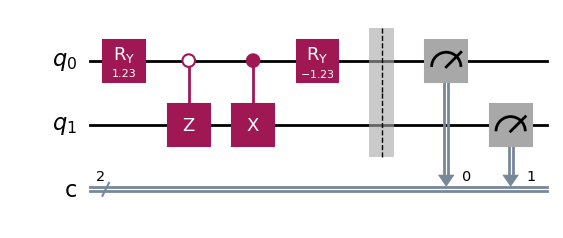

In [11]:

# A = [2 1; 1 -2] = 2*Z + 1*X
# 1. Define A and x
A = np.array([[2, 1], [1, -2]])
c0, c1 = 2.0, 1.0
alpha   = c0 + c1            # = 3


x        = np.array([1, 0], dtype=complex)   # |0>
expected = A @ x



# 3. Build circuit
# q0 = ancilla, q1 = system
qc = QuantumCircuit(2, 2)

# PREP: 
theta = 2 * np.arctan(np.sqrt(c1 / c0))
qc.ry(theta, 0)

# System qubit: x = |0>, no gate needed

qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])

# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 4. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector:", np.round(state.data, 4))
print()
qc.barrier()
qc.measure(0, 0)   # measure ancilla q0 -> classical bit 0
qc.measure(1, 1)   # measure system  q1 -> classical bit 1
# 5. Post-select on ancilla q0 = 0 (even indices: 0, 2)
# and rescale by alpha
result = state.data[[0, 2]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 6. Success probability
prob = np.linalg.norm(state.data[[0, 2]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 7. Draw circuit
print()
qc.draw('mpl')

### Ax: Negative coefficients

Full statevector: [ 0.7071-0.j -0.    -0.j  0.2357-0.j -0.6667+0.j]

LCU result:    [2.1213 0.7071]
Classical Ax:  [2.1213 0.7071]
Match:         True

Success probability: 0.5556  (= ||Ax||^2 / alpha^2 = 5.0000 / 9.0000)



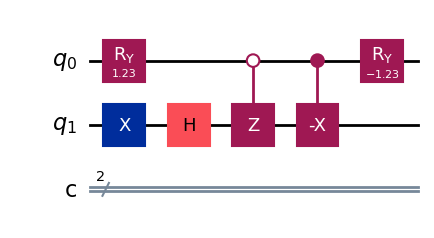

In [12]:
# -------------------------------------------------------
# LCU Example 3: A = 2Z - X, x = |->, alpha = 3
# -------------------------------------------------------

# 1. Define A and x
A = np.array([[2, -1], [-1, -2]])
x        = np.array([1, -1], dtype=complex) / np.sqrt(2)   # |->
c0, c1 = 2.0, -1.0
alpha   = np.abs(c0) + np.abs(c1)   # = 3
expected = A @ x

# 2. PREP angle
# Uses |c0|, |c1| -- sign is handled separately via global_phase

# 3. Phase of each coefficient
phase0 = np.angle(c0)   # 0   (c0 > 0)
phase1 = np.angle(c1)   # pi  (c1 < 0)


# X with global phase of -1 (i.e., phase = pi)
X_matrix = np.array([[0, 1], [1, 0]], dtype=complex)
X_phased = UnitaryGate(-1 * X_matrix, label='-X')   # multiply matrix by -1

# 4. Build circuit
# q0 = ancilla, q1 = system
qc = QuantumCircuit(2, 2)

# PREP: same angle as Example 2 since |c0|, |c1| unchanged
theta = 2 * np.arctan(np.sqrt(np.abs(c1) / np.abs(c0)))
qc.ry(theta, 0)

# System qubit: x = |->
qc.x(1)
qc.h(1)

# SELECT: controlled unitaries
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_phased.control(1, ctrl_state='1'), [0, 1])


# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 5. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector:", np.round(state.data, 4))
print()

# 6. Post-select on ancilla q0 = 0 (even indices: 0, 2)
# and rescale by alpha
result = state.data[[0, 2]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 7. Success probability
prob = np.linalg.norm(state.data[[0, 2]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 8. Draw circuit
print()
qc.draw('mpl')

### Ax: 4x4 example

A =
[[ 0.75  0.25  0.    0.  ]
 [ 0.25  0.75  0.    0.  ]
 [ 0.    0.   -0.75  0.25]
 [ 0.    0.    0.25 -0.75]]

Classical x = [1. 0. 0. 0.]

Classical A*x = [0.75 0.25 0.   0.  ]

theta = 1.0472 rad


<IPython.core.display.Latex object>


Quantum result (post-selected on ancilla=|0>, rescaled by alpha):
[0.75 0.25 0.   0.  ]

Classical A*x:
[0.75 0.25 0.   0.  ]

Results match: True

Success probability = 0.6250  (62.5%)


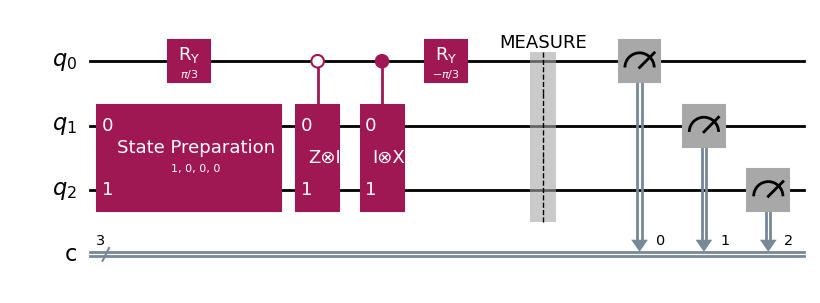

In [7]:
# ── Pauli matrices ────────────────────────────────────────────────────────
I = np.eye(2, dtype=complex)
Z = np.array([[1,  0], [0, -1]], dtype=complex)
X = np.array([[0,  1], [1,  0]], dtype=complex)

# ── Matrix A = 3/4 (Z⊗I) + 1/4 (I⊗X) ────────────────────────────────────
c0, c1 = 3/4, 1/4
alpha   = c0 + c1                        # = 1.0

A = c0 * np.kron(Z, I) + c1 * np.kron(I, X)
print("A =")
print(np.real_if_close(A))

# ── Classical result  x = |00> = (1,0,0,0) ───────────────────────────────
x = np.array([1, 0, 0, 0], dtype=complex)
x = x/np.linalg.norm(x)  # normalize to unit length
print("\nClassical x =", np.real_if_close(x))
Ax_classical = A @ x
print("\nClassical A*x =", np.real_if_close(Ax_classical))

# ── Ancilla preparation angle ─────────────────────────────────────────────
theta = 2 * np.arctan(np.sqrt(c1 / c0)) 
print(f"\ntheta = {theta:.4f} rad")

# ── Custom 2-qubit gates with explicit labels ─────────────────────────────
ZI_gate = UnitaryGate(np.kron(Z, I), label='Z⊗I')
IX_gate = UnitaryGate(np.kron(I, X), label='I⊗X')

# ── Quantum circuit: q0 = ancilla, q1,q2 = system qubits ─────────────────
qc = QuantumCircuit(3, 3)

# Step 1: prepare ancilla — encodes weights sqrt(3/4)|0> + sqrt(1/4)|1>
qc.ry(theta, 0)

qc.append(StatePreparation(x), [1, 2])  # prepare system state |00>

# Step 2: controlled-(Z⊗I) when ancilla q0=|0>
qc.append(ZI_gate.control(1, ctrl_state='0'), [0, 1, 2])

# Step 3: controlled-(I⊗X) when ancilla q0=|1>
qc.append(IX_gate.control(1, ctrl_state='1'), [0, 1, 2])

# Step 4: uncompute ancilla
qc.ry(-theta, 0)

sv = Statevector.from_instruction(qc)
display(sv.draw('latex'))
        
# Step 5: measure all qubits
qc.barrier(label="MEASURE")
qc.measure([0, 1, 2], [0, 1, 2])

# Post-select on ancilla q0=0: indices {0, 2, 4, 6} of the statevector
result = np.real_if_close(sv.data[[0, 2, 4, 6]]) * alpha
print("\nQuantum result (post-selected on ancilla=|0>, rescaled by alpha):")
print(np.round(result, 6))

print("\nClassical A*x:")
print(np.real_if_close(Ax_classical))

print("\nResults match:", np.allclose(result, Ax_classical))

# ── Success probability ───────────────────────────────────────────────────
P_success = np.linalg.norm(A @ x)**2 / alpha**2
print(f"\nSuccess probability = {P_success:.4f}  ({P_success*100:.1f}%)")

# ── Save circuit diagram ──────────────────────────────────────────────────
qc.draw('mpl')


## Pauli Expansion

In [14]:
A = np.array([
    [1, 0, 0, 0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.5, 0, 0, 1]
])
pauliSplit = SparsePauliOp.from_operator(A)
print(pauliSplit.paulis)
print(pauliSplit.coeffs)



['II', 'XX', 'YY']
[ 1.  +0.j  0.25+0.j -0.25+0.j]


### Reconstruction

In [15]:
B = np.zeros_like(A,dtype=complex)
for i, (pauli, coeff) in enumerate(zip(pauliSplit.paulis, pauliSplit.coeffs)):
    print(f"\nPauli term {i}:")
    print(f"Coefficient: {coeff}")
    print(f"Pauli string: {pauli.to_label()}")
    print(pauli.to_matrix())
    B += coeff * pauli.to_matrix()

print("\nReconstructed A from Pauli decomposition:")
print(np.real_if_close(B))


Pauli term 0:
Coefficient: (1+0j)
Pauli string: II
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

Pauli term 1:
Coefficient: (0.25+0j)
Pauli string: XX
[[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]]

Pauli term 2:
Coefficient: (-0.25+0j)
Pauli string: YY
[[ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  1.-0.j  0.+0.j]
 [ 0.+0.j  1.-0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j]]

Reconstructed A from Pauli decomposition:
[[1.  0.  0.  0.5]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.5 0.  0.  1. ]]


## Performing Ax using LCU_Ax

{'alpha': np.float64(1.5), 'num_system': 2, 'num_ancilla': 2, 'coeffs': array([ 1.  +0.j,  0.25+0.j, -0.25+0.j]), 'pauli_split': SparsePauliOp(['II', 'XX', 'YY'],
              coeffs=[ 1.  +0.j,  0.25+0.j, -0.25+0.j]), 'ancilla_zero_stride': 4}
Expected output: [0.6 0.8 0.  0.3]
Quantum output: [0.6 0.8 0.  0.3]
Success probability: 0.4844


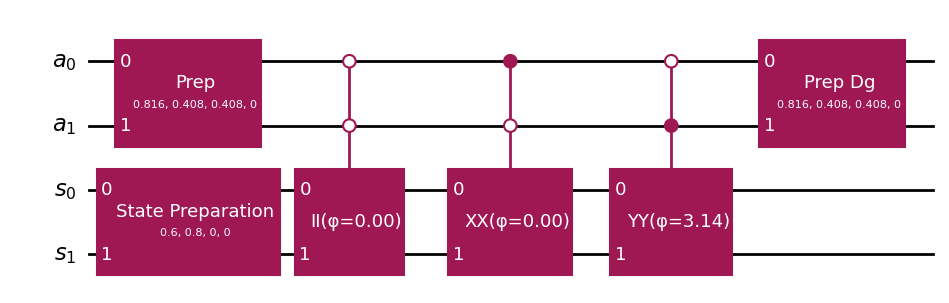

In [15]:
A = np.array([
    [1, 0, 0, 0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

expected_output = A @ x

# Create circuit
qc, metadata = LCU_Ax(A, x)
print(metadata)

# Get the exact statevector
final_state = Statevector(qc)
num_system = metadata['num_system']
num_ancilla = metadata['num_ancilla']
alpha = metadata['alpha']
stride = metadata['ancilla_zero_stride']

res_vector   = final_state.data[::2**num_ancilla] * alpha
success_prob = np.linalg.norm(final_state.data[::2**num_ancilla])**2

print("Expected output:", np.round(np.real_if_close(expected_output), 4))
print("Quantum output:", np.round(np.real_if_close(res_vector), 4))
print("Success probability:", np.round(success_prob, 4))
qc.draw('mpl')

## LCU truss stiffness matrices

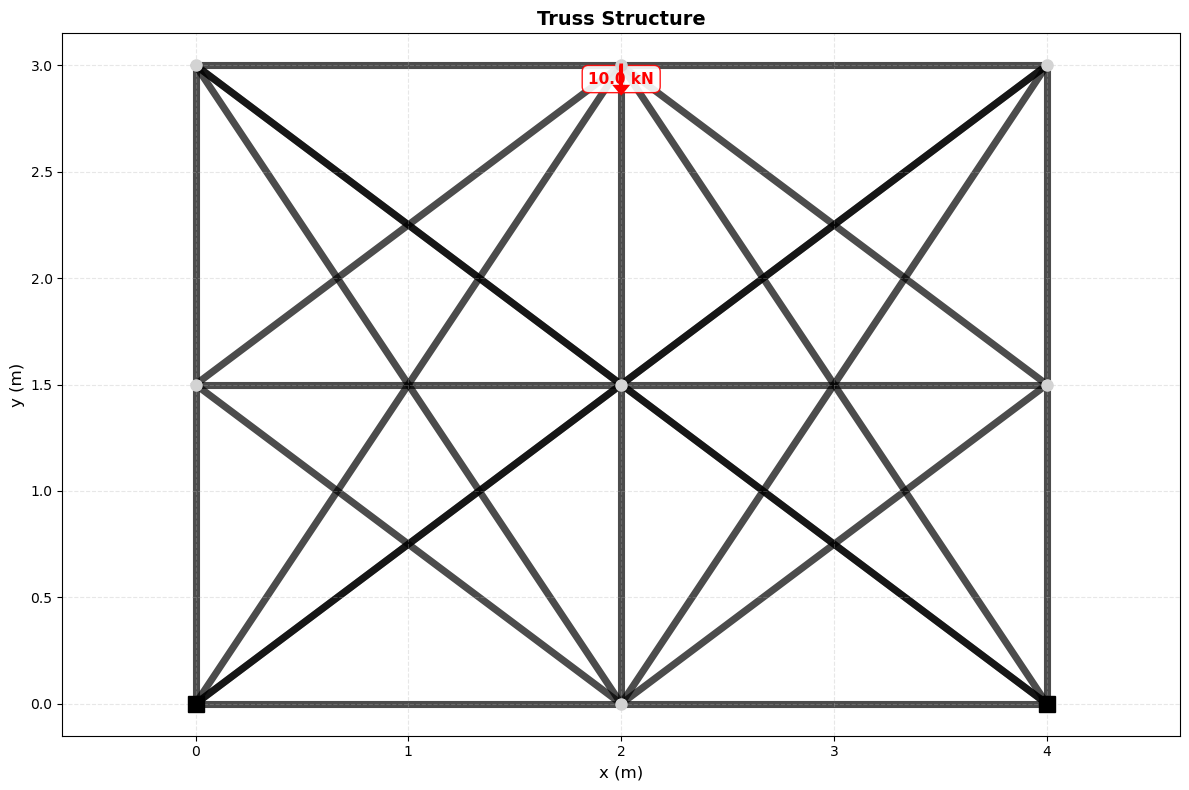

Size of K_full: (18, 18)
Size of K: (14, 14)
Size of sub-matrix A: (8, 8)
Number of Pauli terms: 24
Ancilla qubits needed: 5
System qubits needed: 3
Total qubits: 8
Normalization α: 4.3793e+08


In [16]:
fem_model= truss3x3()
fem_model.plot_truss()
K_full = fem_model.assemble_stiffness()
print("Size of K_full:", K_full.shape)
all_dofs = set(range(fem_model.n_dofs))
free_dofs = list(all_dofs - set(fem_model.fixed_dofs))
K = K_full[np.ix_(free_dofs, free_dofs)]
f = fem_model.loads[free_dofs]
print("Size of K:", K.shape)
N = 8
A = K[:N, :N]  # Just take a N x N block for testing
print("Size of sub-matrix A:", A.shape)
pauliSplit = SparsePauliOp.from_operator(A)
print("Number of Pauli terms:",pauliSplit.coeffs.shape[0])

# Resource requirements
num_ancilla = int(np.ceil(np.log2(pauliSplit.coeffs.shape[0])))  # One ancilla per Pauli term
num_system = int(np.ceil(np.log2(N)))
print(f"Ancilla qubits needed: {num_ancilla}")
print(f"System qubits needed: {num_system}")
print(f"Total qubits: {num_ancilla + num_system}")

# Normalization constant
alpha = np.sum(np.abs(pauliSplit.coeffs))
print(f"Normalization α: {alpha:.4e}")

## FEM Matrix Circuit analysis

In [17]:
# Create a simple test vector
x = np.zeros(8)
x[0] = 1.0  # Unit displacement at first DOF

# Create LCU circuit
qc, metadata = LCU_Ax(A, x, mode='statevector')

# Analyze circuit
print(f"Circuit depth: {qc.depth()}")
print(f"Number of qubits: {qc.num_qubits}")

# Decompose to basis gates
qc_decomposed = qc.decompose(reps=3)
print(f"\nAfter decomposition to basis gates:")
print(f"Circuit depth: {qc_decomposed.depth()}")
print(f"Total gates: {sum(qc_decomposed.count_ops().values())}")

Circuit depth: 26
Number of qubits: 8

After decomposition to basis gates:
Circuit depth: 1129
Total gates: 1775


## Computing f^T A x    

Expected output (f^T A x): 0.85
Quantum output (f^T A x): 0.8441


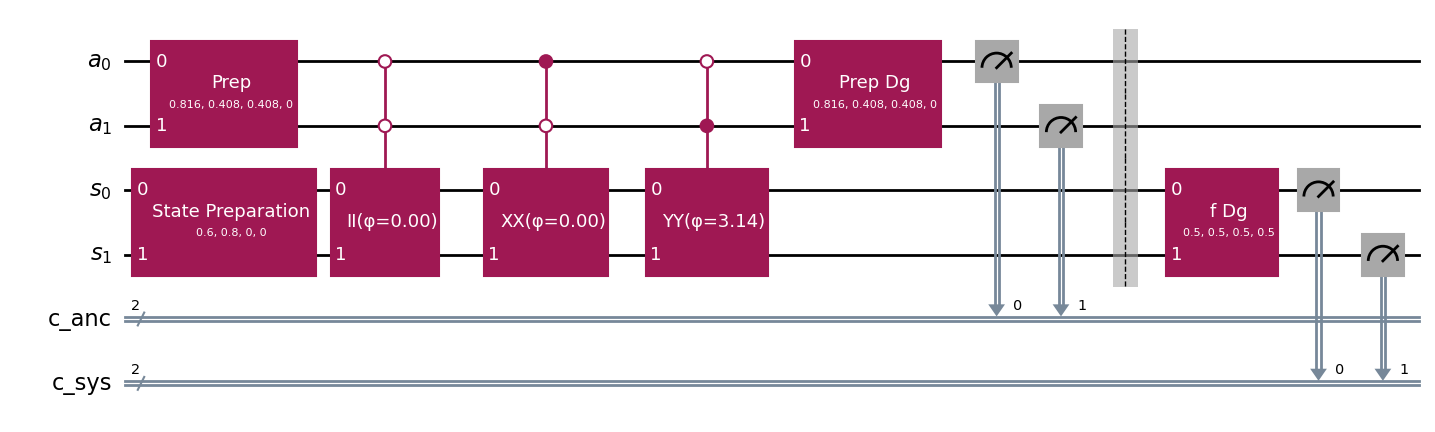

In [18]:
A = np.array([
    [1, 0, 0, 0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

f = np.array([1, 1, 1, 1], dtype=complex)
f = f / np.linalg.norm(f)  # Normalize f to unit length

expected_output = f @ A @ x
print("Expected output (f^T A x):", np.round(np.real_if_close(expected_output), 4))

[result, qc, metadata] = LCU_fTAx(f, A, x, shots=10000)
print("Quantum output (f^T A x):", np.round(np.real_if_close(result), 4))
qc.draw('mpl')
